## CNN-based defect classification with visual interpretability using Grad-CAM

In [1]:
import sys
from pathlib import Path

# Path setup
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Seed 
from src.utils.seed import set_seed
set_seed(42)

# Imports
import torch
from src.data_operations.dataset import build_dataloaders
from src.data_operations.transforms import get_train_transforms, get_val_transforms

Seed set to 42


In [2]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
GPU name: NVIDIA GeForce RTX 4070 Ti SUPER


In [3]:
splits_root = project_root / "data" / "splits"

train_loader, val_loader, test_loader = build_dataloaders(
    root            = splits_root,
    train_transform = get_train_transforms(),
    val_transform   = get_val_transforms(),
    batch_size      = 32,
    num_workers     = 4,
    pin_memory      = True,
)
print(train_loader)

In [4]:
batch = next(iter(train_loader))
print(batch["image"].shape)    # torch.Size([32, 3, 224, 224])
print(batch["label"].shape)    # torch.Size([32])
print(batch["image_path"][0])  # data/splits/train/IMAGES/crazing_1.jpg

torch.Size([32, 3, 224, 224])
torch.Size([32])
/home/lautivuelos/industrial-defect-detection/data/splits/train/IMAGES/patches_8.jpg


In [5]:
from src.models.cnn.resnet import build_resnet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_resnet(num_classes=6)
model = model.to(device)

model.print_trainable_layers()

params = model.count_parameters()
print(f"Trainable: {params['trainable']:,}")
print(f"Total:     {params['total']:,}")


Layer                Status
--------------------------------
conv1                frozen
bn1                  frozen
relu                 frozen
maxpool              frozen
layer1               frozen
layer2               frozen
layer3               trainable
layer4               trainable
avgpool              frozen
fc                   trainable
Trainable: 22,075,398
Total:     23,520,326


In [6]:
from src.training.train import train, evaluate
from src.models.cnn.resnet import build_resnet

model = build_resnet(num_classes=6)

train(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = 10,
)

Epoch 1/10
  Train — loss: 0.2601  acc: 0.9322
  Val   — loss: 0.1050  acc: 0.9667
Epoch 2/10
  Train — loss: 0.1046  acc: 0.9745
  Val   — loss: 0.2170  acc: 0.9630
Epoch 3/10
  Train — loss: 0.1086  acc: 0.9777
  Val   — loss: 0.0072  acc: 0.9963
Epoch 4/10
  Train — loss: 0.1550  acc: 0.9785
  Val   — loss: 0.0355  acc: 0.9926
Epoch 5/10
  Train — loss: 0.0764  acc: 0.9833
  Val   — loss: 0.0069  acc: 0.9963
Epoch 6/10
  Train — loss: 0.0396  acc: 0.9920
  Val   — loss: 0.0033  acc: 0.9963
Epoch 7/10
  Train — loss: 0.0789  acc: 0.9848
  Val   — loss: 0.0365  acc: 0.9963
Epoch 8/10
  Train — loss: 0.0462  acc: 0.9856
  Val   — loss: 0.0153  acc: 1.0000
Epoch 9/10
  Train — loss: 0.0139  acc: 0.9976
  Val   — loss: 0.0010  acc: 1.0000
Epoch 10/10
  Train — loss: 0.0286  acc: 0.9952
  Val   — loss: 0.0017  acc: 1.0000


In [7]:
evaluate(model, test_loader)

loss: 0.0008  acc: 1.0000


(0.0008453440913693081, 1.0)

## Let's try on random images from the test set

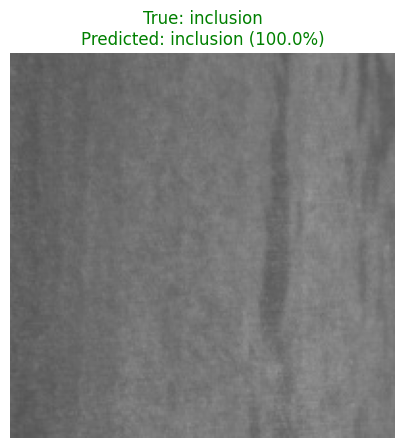


Class probabilities:
  inclusion            0.9999  █████████████████████████████
  scratches            0.0001  
  pitted_surface       0.0000  
  rolled-in_scale      0.0000  
  crazing              0.0000  
  patches              0.0000  


In [8]:
import random
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

# ── Pick a random sample ───────────────────────────────────────────────────
idx    = random.randint(0, len(test_loader.dataset) - 1)
sample = test_loader.dataset[idx]

image_path   = sample["image_path"]
true_label   = test_loader.dataset.classes[sample["label"]]

# ── Run inference ──────────────────────────────────────────────────────────
model.eval()
model.to(device)

with torch.no_grad():
    x      = sample["image"].unsqueeze(0).to(device)  # [1, 3, 224, 224]
    output = model(x)                                  # [1, 6] logits
    probs  = F.softmax(output, dim=1).squeeze()        # [6] probabilities

# ── Get prediction ─────────────────────────────────────────────────────────
classes        = test_loader.dataset.classes
pred_idx       = probs.argmax().item()
pred_class     = classes[pred_idx]
pred_conf      = probs[pred_idx].item()

# ── Display ────────────────────────────────────────────────────────────────
image = Image.open(image_path)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title(
    f"True: {true_label}\n"
    f"Predicted: {pred_class} ({pred_conf:.1%})",
    fontsize=12,
    color="green" if pred_class == true_label else "red"
)
plt.axis("off")
plt.show()

# ── All class probabilities ────────────────────────────────────────────────
print("\nClass probabilities:")
for cls, prob in sorted(zip(classes, probs.tolist()), key=lambda x: -x[1]):
    bar = "█" * int(prob * 30)
    print(f"  {cls:<20} {prob:.4f}  {bar}")

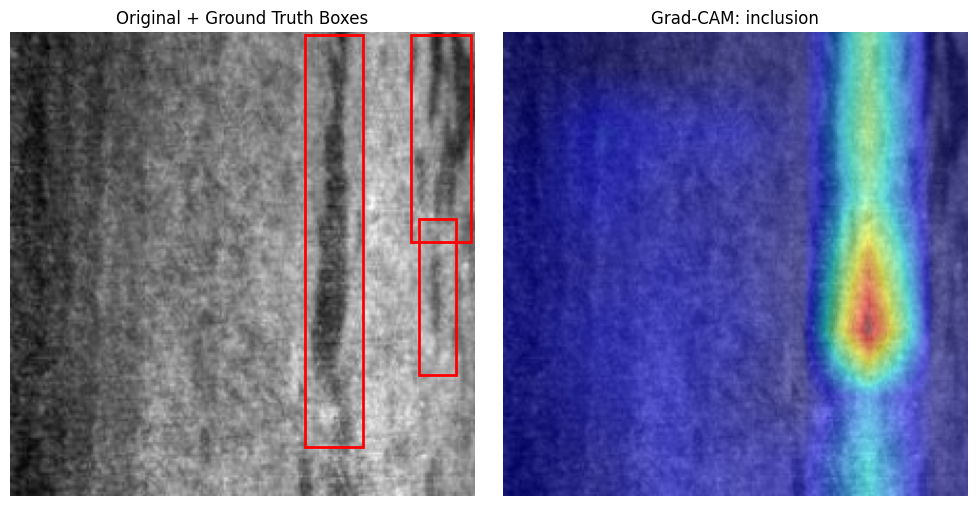

In [9]:
from src.interpretability.gradcam import GradCAM

cam_resnet = GradCAM(model, target_layer=model.backbone.layer4)

sample  = test_loader.dataset[idx]
boxes   = test_loader.dataset.get_boxes(sample["image_path"])
classes = test_loader.dataset.classes

cam_resnet.visualize(sample, classes, boxes=boxes)

## Let's check for one of each class


── crazing ──


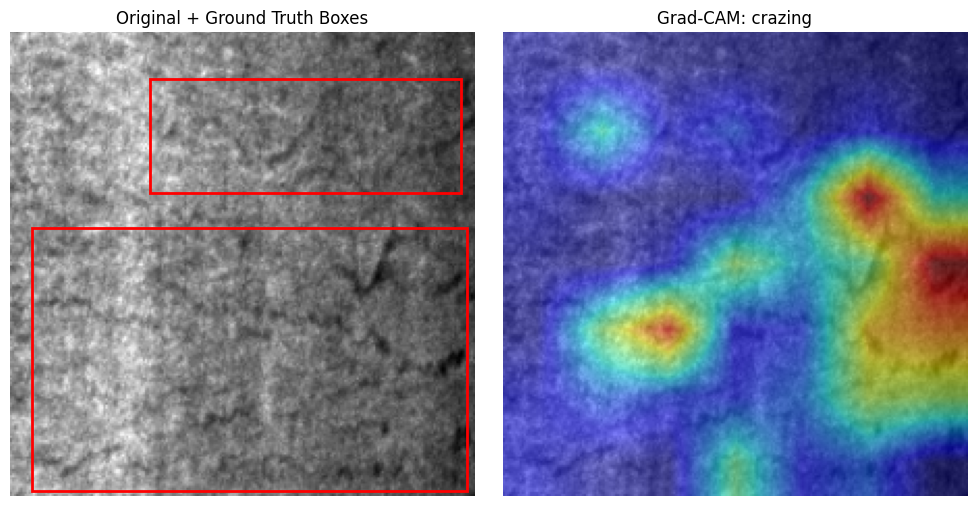


── inclusion ──


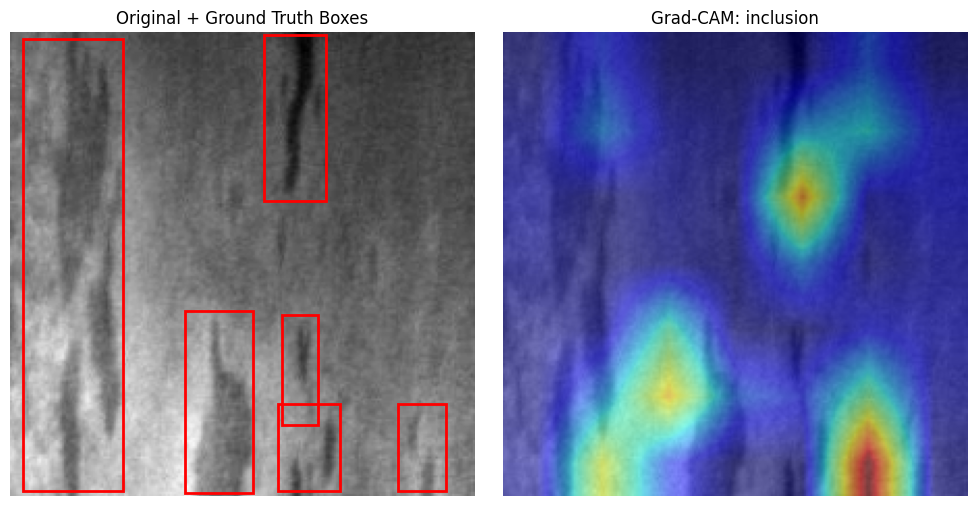


── patches ──


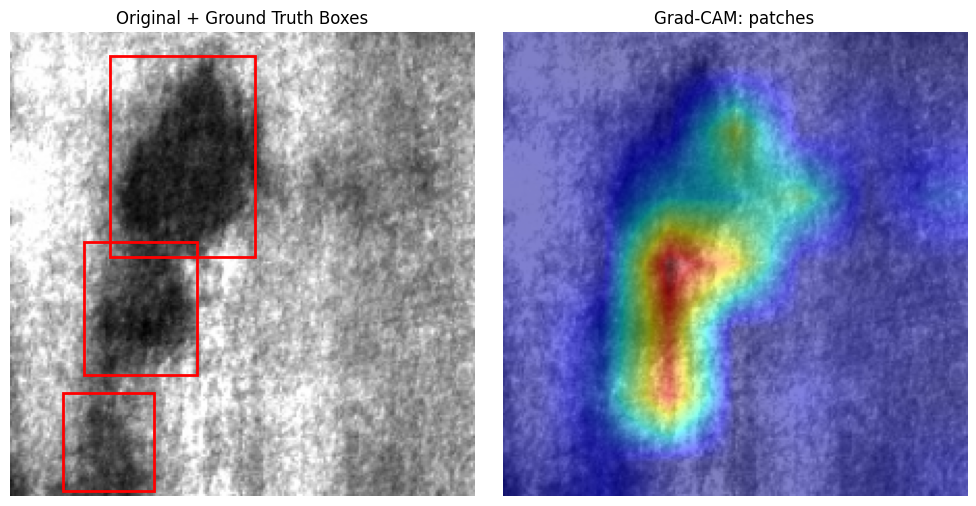


── pitted_surface ──


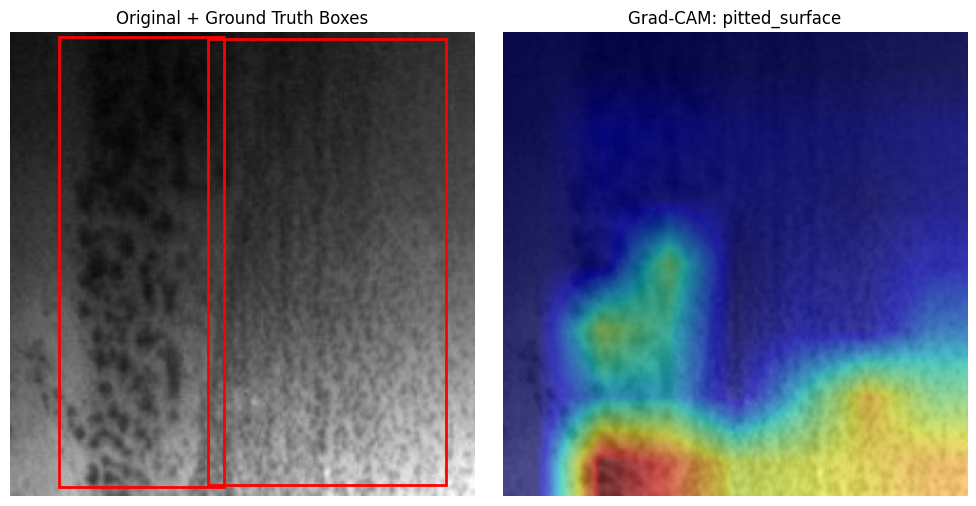


── rolled-in_scale ──


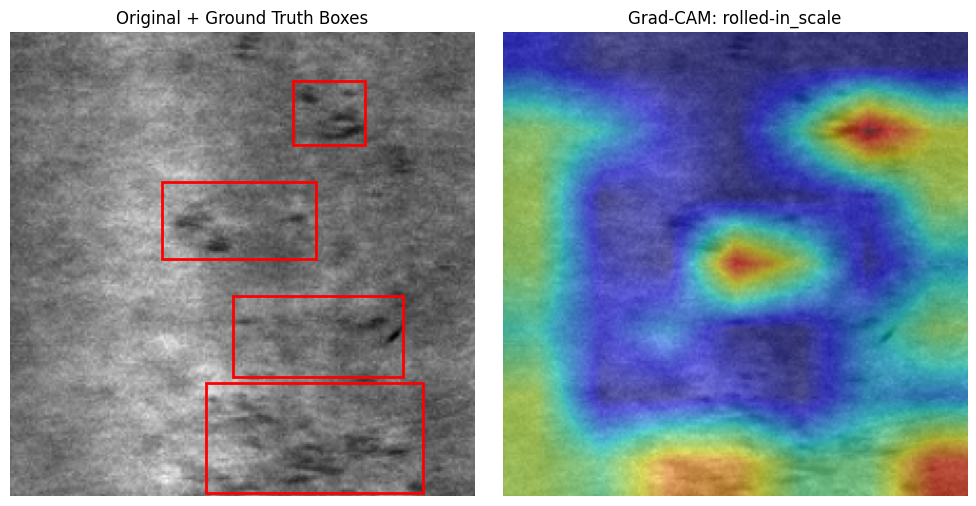


── scratches ──


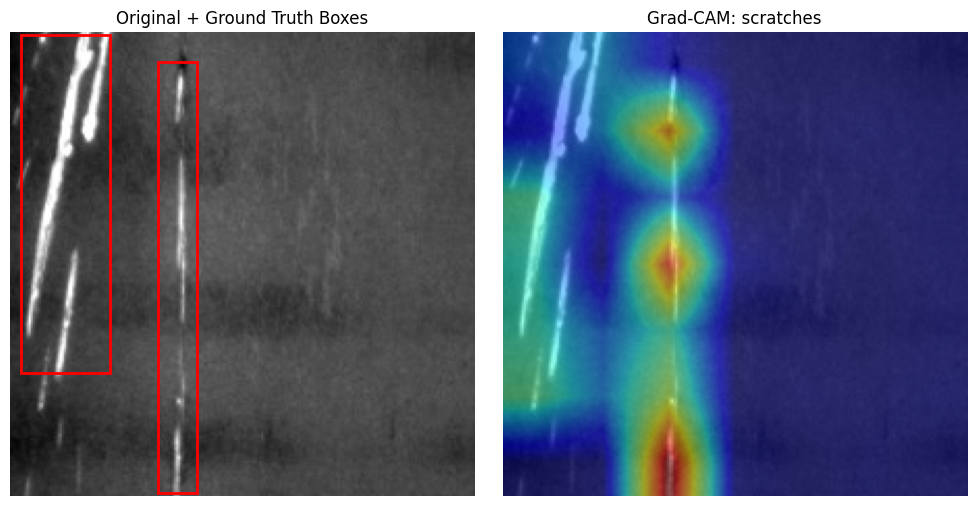

In [11]:
examples = {}

for idx in range(len(test_loader.dataset)):
    sample     = test_loader.dataset[idx]
    class_name = test_loader.dataset.classes[sample["label"]]

    if class_name not in examples:
        examples[class_name] = idx

    # stop early once all 6 classes found
    if len(examples) == len(test_loader.dataset.classes):
        break

# visualise one per class
for class_name, idx in examples.items():
    sample  = test_loader.dataset[idx]
    boxes   = test_loader.dataset.get_boxes(sample["image_path"])
    classes = test_loader.dataset.classes
    print(f"\n── {class_name} ──")
    cam_resnet.visualize(sample, classes, boxes=boxes)

## Grad-CAM Analysis

Attention focuses closely on ground truth boxes for localised defects — scratches, patches, and rolled-in scale produce tight, well-aligned heatmaps. For distributed defects (crazing and pitted surface), the heatmap concentrates on the most visually distinct regions rather than reflecting the full spatial spread of the defect.

The inclusion example shown is a particular case — individual instances are small and localised, but their high density across the surface causes the heatmap to activate on just a few specific defect sites rather than broadly across all of them.